## Instalación de Librerías Clave
Antes de iniciar el análisis, es fundamental instalar las librerías especializadas que permitirán construir y evaluar el sistema de recomendación. Este paso garantiza que el entorno cuente con las herramientas necesarias para el procesamiento eficiente de datos y el desarrollo de modelos avanzados.

In [21]:
!pip install lightfm

# Resumen Ejecutivo
Este notebook presenta el desarrollo y análisis de un sistema avanzado de recomendación de destinos turísticos, orientado a maximizar la personalización y el valor comercial en la industria de viajes. El objetivo es construir una solución robusta que recomiende destinos relevantes a cada usuario, anticipe la demanda y optimice la toma de decisiones empresariales.

**Enfoque Metodológico:**
El pipeline integra técnicas de ciencia de datos, modelado predictivo y análisis de demanda, abarcando desde la ingeniería de características y validación de modelos, hasta la generación de recomendaciones y la predicción de demanda con Prophet. Se enfatiza la importancia de la calidad de los datos y la retroalimentación continua para transformar el sistema en una herramienta estratégica de alto impacto.

**Principales Hallazgos:**
- Los modelos de recomendación entrenados con datos sintéticos presentan limitaciones significativas en la capacidad de personalización y predicción, con métricas de evaluación (AUC) cercanas a 0.5, lo que indica un rendimiento similar al azar.
- La falta de correlación entre las preferencias declaradas y las interacciones observadas limita el aprendizaje de patrones útiles.
- La predicción de demanda con Prophet revela tendencias estacionales, pero su precisión depende de la calidad y granularidad de los datos históricos.
- Se identificó la necesidad crítica de integrar datos reales y representativos para mejorar la relevancia y el impacto del sistema.
- El pipeline construido es funcional y escalable, preparado para automatización y actualización periódica en entornos productivos.

**Implicaciones Estratégicas:**
Las recomendaciones y conclusiones del análisis permiten a la organización identificar oportunidades de mejora, optimizar recursos y fortalecer la fidelización de clientes. El sistema está listo para integrarse en operaciones reales, facilitando la automatización y la adaptación continua según el comportamiento de los usuarios.

---

# Notebook de Sistema de Recomendación de Viajes: Estrategia, Ciencia de Datos y Valor de Negocio
Este notebook documenta el proceso integral de desarrollo y análisis de un sistema de recomendación de destinos de viaje, abordando tanto los retos técnicos como estratégicos que enfrenta la industria turística moderna.

El enfoque adoptado es iterativo y profesional, combinando técnicas avanzadas de ciencia de datos, modelado predictivo y análisis de demanda para maximizar el valor de negocio. A lo largo del documento se exploran las mejores prácticas en ingeniería de características, validación de modelos y diagnóstico de resultados, siempre con una visión orientada a la toma de decisiones empresariales.

**Propósito y Alcance:**
- Construir un sistema robusto capaz de recomendar destinos personalizados, optimizando la experiencia del usuario y la conversión comercial.
- Diagnosticar las limitaciones inherentes a los datos y modelos, proponiendo soluciones estratégicas para su mejora continua.
- Integrar la predicción de demanda como herramienta clave para la planificación operativa y comercial.

**Valor para el negocio:**
Este análisis no solo busca demostrar la funcionalidad técnica del sistema, sino también generar insights accionables que permitan a la organización anticipar tendencias, optimizar recursos y fortalecer la fidelización de clientes.

**Estructura del notebook:**
1. Contexto y configuración del entorno.
2. Carga, validación y análisis exploratorio de datos.
3. Preprocesamiento e ingeniería de características.
4. Modelado iterativo y evaluación.
5. Diagnóstico avanzado y recomendaciones estratégicas.
6. Predicción de demanda y planificación.
7. Exportación de artefactos para producción.

A lo largo de cada sección se enfatiza la importancia de la calidad de los datos, la validación continua y la integración de feedback real para transformar el sistema en una herramienta estratégica de alto impacto.

---

## Representación Visual: Diagrama Conceptual del Sistema
Para facilitar la comprensión del flujo y la lógica del sistema de recomendación y predicción de demanda, se recomienda incluir un diagrama conceptual. Este diagrama puede ser elaborado en herramientas como draw.io, Lucidchart o PowerPoint, y debe mostrar:
- **Entradas:** Datos de usuarios, destinos, historial, reseñas.
- **Procesos:** Preprocesamiento, ingeniería de características, modelado de recomendación (LightFM), predicción de demanda (Prophet).
- **Salidas:** Recomendaciones personalizadas, proyecciones de demanda, entregables para negocio.
- **Retroalimentación:** Integración de datos reales y actualización continua del pipeline.

Ejemplo de estructura visual:
```
                                [Datos de Usuarios]   [Datos de Destinos]   [Historial/Reseñas]
                                        |                  |                  |
                                        +--------[Preprocesamiento]----------+
                                                        |
                                        [Ingeniería de Características]
                                                        |
                                        +---------[Modelos]----------+
                                        |                            |
                                [Recomendador LightFM]     [Predicción Prophet]
                                        |                            |
                                [Recomendaciones]        [Proyección de Demanda]
                                        |                            |
                                        +---------[Entregables y Feedback]-----+
```

# 1. Configuración del Entorno
En esta sección se establecen las bases técnicas necesarias para el desarrollo del sistema de recomendación. Se detallan los pasos para la instalación de librerías especializadas y la importación de dependencias clave, asegurando un entorno robusto y reproducible para el análisis y modelado de datos.

## 1.1 Instalación de Librerías
**Descripción:** Se instala la librería `lightfm`, fundamental para la construcción de sistemas de recomendación modernos.
**Justificación:** LightFM es una librería de Python especializada en modelos de recomendación híbridos, capaz de manejar tanto feedback implícito (visitas) como explícito (calificaciones). Su capacidad para incorporar características de usuario y destino permite mitigar el problema de "arranque en frío" y mejorar la personalización, lo que la convierte en una herramienta estratégica para proyectos de analítica avanzada en turismo.

## Carga y Validación de Datos


In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import warnings
warnings.filterwarnings("ignore")
import os

from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# 2. Carga y Análisis Inicial de Datos
En esta etapa se realiza la carga de los conjuntos de datos fundamentales y se lleva a cabo una primera inspección para validar su integridad y relevancia. Este proceso es clave para garantizar la calidad de la información utilizada en el sistema de recomendación y para identificar posibles retos en la estructura y el contenido de los datos.

## Resumen de la Sección: Carga y Validación de Datos

**Objetivo:** Importar los datos necesarios para el sistema de recomendación y validar su integridad antes del análisis.

**Principales pasos:**
- Carga de archivos CSV con información de destinos, usuarios, reseñas y registros históricos.
- Validación de formatos, tipos de datos y presencia de valores nulos.
- Exploración inicial para asegurar la calidad y consistencia de los datos.

**Resultados esperados:**
- Datos correctamente importados y listos para preprocesamiento.
- Identificación de posibles problemas de calidad que puedan requerir limpieza adicional.

**Limitaciones y supuestos:**
- Se asume que los archivos fuente están completos y actualizados.
- La validación se basa en reglas generales; errores sutiles pueden requerir revisión manual.
- No se realiza imputación avanzada en esta etapa, solo limpieza básica.

---

## 2.1 Carga de los Conjuntos de Datos
**Descripción:** Se cargan los cuatro archivos CSV principales: usuarios, historial de visitas, reseñas y destinos, que constituyen la base informacional del sistema.
**Justificación:** Este paso inicial permite comprender la estructura y el volumen de los datos disponibles, facilitando la identificación de oportunidades y limitaciones para el modelado. La inspección de las dimensiones de cada tabla es esencial para dimensionar el alcance del análisis y anticipar posibles retos en la integración y limpieza de datos.

---
**Análisis del Resultado:**
La correcta carga y validación de los datos es fundamental para asegurar la fiabilidad de los resultados posteriores. Se recomienda documentar cualquier inconsistencia detectada y establecer mecanismos de control de calidad para futuras actualizaciones del pipeline.

In [ ]:
# Cargar los datos de forma robusta
import os

try:
    # __file__ no existe en notebooks interactivos, así que usamos una variable que Jupyter sí define.
    # Si __vsc_ipynb_file__ existe, usamos su directorio como base.
    base_path = os.path.abspath(os.path.join('\Module3\DATA'))
    print(f"Ruta a los datos construida dinámicamente: {base_path}")

    df_users = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Users.csv"))
    df_history = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_UserHistory.csv"))
    df_reviews = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Reviews.csv"))
    df_dest = pd.read_csv(os.path.join(base_path, "Expanded_Destinations.csv"))

    print("Archivos cargados exitosamente.")

except NameError:
    # Fallback por si __vsc_ipynb_file__ no estuviera definido en otro entorno
    print("La variable __vsc_ipynb_file__ no está definida. Intentando con ruta relativa al proyecto.")
    # Asumimos que el kernel se ejecuta en la raíz del proyecto
    base_path = r"Module3/DATA"
    df_users = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Users.csv"))
    df_history = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_UserHistory.csv"))
    df_reviews = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Reviews.csv"))
    df_dest = pd.read_csv(os.path.join(base_path, "Expanded_Destinations.csv"))
    print("Archivos cargados exitosamente con ruta relativa al proyecto.")

except FileNotFoundError as e:
    print(f"No se pudieron cargar los archivos. Error: {e}")
    print("Por favor, verifique que la estructura de carpetas es la correcta y que los archivos de datos existen.")

print("Usuarios:", df_users.shape, "Historial:", df_history.shape,
      "Reseñas:", df_reviews.shape, "Destinos:", df_dest.shape)

Ruta a los datos construida dinámicamente: /content
Archivos cargados exitosamente.
Usuarios: (999, 7) Historial: (999, 5) Reseñas: (999, 5) Destinos: (1000, 6)



La carga de datos se realiza con manejo de excepciones para asegurar la integridad y disponibilidad de la información. Este enfoque profesional permite detectar y comunicar errores de forma clara, facilitando la depuración y el control de calidad en el pipeline analítico.

# **3. Preprocesamiento e Ingeniería de Características**
En esta sección se realiza la limpieza, transformación y enriquecimiento de los datos, preparando la información para su uso óptimo en los modelos de recomendación. El preprocesamiento profesional garantiza que los datos sean consistentes, relevantes y estructurados, lo que maximiza la capacidad predictiva y la robustez del sistema.

## Resumen de la Sección: Preprocesamiento e Ingeniería de Características

**Objetivo:** Limpiar, transformar y enriquecer los datos para optimizar su uso en los modelos de recomendación.

**Principales pasos:**
- Limpieza de datos y manejo de valores nulos.
- Transformación de variables categóricas y textuales.
- Ingeniería de características para extraer información relevante (ej. preferencias de usuario, atributos de destinos).

**Resultados esperados:**
- Datos estructurados y consistentes, listos para modelado.
- Mejor representación de preferencias y atributos para personalización.

**Limitaciones y supuestos:**
- Se asume que las transformaciones propuestas son suficientes para capturar la información relevante.
- La ingeniería de características se basa en reglas heurísticas; pueden existir relaciones no modeladas.
- No se realiza imputación avanzada ni generación automática de nuevas variables.

---

## **3.1. Separación de Preferencias de Usuario**
**Descripción:** La columna `Preferences` en `df_users` contiene múltiples valores en una sola cadena de texto (ej. "Beaches, Historical"). Se divide esta columna en `Preference_1` y `Preference_2` para facilitar el análisis.
**Justificación:** Separar las preferencias en columnas individuales permite al modelo tratar cada preferencia como una categoría única, mejorando la granularidad y la capacidad de personalización en las recomendaciones. Esta transformación es una práctica profesional en la ingeniería de características, orientada a maximizar el valor informativo de los datos.

---
**Análisis del Resultado:**
El DataFrame `df_users` ahora cuenta con dos nuevas columnas, `Preference_1` y `Preference_2`, y la columna original `Preferences` ha sido eliminada. Este formato estructurado facilita el uso eficiente de las preferencias en el modelado y la interpretación de resultados.

In [24]:
df_users[['Preference_1', 'Preference_2']] = df_users['Preferences'].str.split(', ', expand=True)
df_users.drop('Preferences', axis=1, inplace=True)
df_users.head()

,UserID,Name,Email,Gender,NumberOfAdults,NumberOfChildren,Preference_1,Preference_2
0,1,Kavya,kavya@example.com,Female,1,0,Beaches,Historical
1,2,Rohan,rohan@example.com,Male,2,2,Nature,Adventure
2,3,Kavya,kavya@example.com,Female,2,0,City,Historical
3,4,Anika,anika@example.com,Female,1,0,Beaches,Historical
4,5,Tanvi,tanvi@example.com,Female,2,2,Nature,Adventure


## 3.2. Normalización de la Popularidad del Destino
**Descripción:** Se crea una nueva columna `Popularity_normalized` en `df_dest`, escalando la columna `Popularity` a un rango entre 0 y 1.
**Justificación:** La normalización de variables numéricas es una práctica profesional que mejora la comparabilidad entre características y evita sesgos en el entrenamiento de modelos. Aunque LightFM es robusto ante diferencias de escala, la normalización asegura que la popularidad sea utilizada de manera óptima como atributo relevante en el sistema de recomendación.

---
**Análisis del Resultado:**
La nueva columna `Popularity_normalized` proporciona una escala consistente y lista para ser utilizada en el modelado, contribuyendo a la robustez y precisión de las recomendaciones generadas.

In [25]:
scaler = MinMaxScaler()
df_dest['Popularity_normalized'] = scaler.fit_transform(df_dest[['Popularity']])

## 3.3. Análisis Exploratorio Visual (EDA)
**Descripción:** Se generan cuatro gráficos para visualizar las distribuciones y patrones clave en los datos, proporcionando una visión integral de las variables más relevantes.
**Justificación:** El análisis exploratorio de datos (EDA) es esencial para identificar sesgos, tendencias estacionales y diferencias demográficas antes de la construcción de modelos. Esta etapa profesional permite anticipar retos, validar hipótesis y fundamentar decisiones estratégicas en el pipeline de recomendación.

---
**Análisis del Resultado:**
Los gráficos revelan:
1.  **Distribución de Ratings:** Permite identificar la frecuencia y sesgo de las calificaciones.
2.  **Popularidad por Tipo:** Muestra qué tipos de destinos son generalmente más populares, informando la lógica de recomendación.
3.  **Preferencias por Género:** Ayuda a detectar diferencias en las preferencias de viaje entre géneros, útil para segmentación.
4.  **Estacionalidad:** Identifica picos y valles en el número de visitas a lo largo del año, clave para la planificación operativa y campañas de marketing.

### Resumen de la Sección: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Explorar visualmente los datos para identificar patrones, sesgos y tendencias relevantes antes del modelado.

**Principales pasos:**
- Generación de gráficos para analizar distribuciones, popularidad, preferencias y estacionalidad.
- Interpretación de resultados para fundamentar decisiones de modelado y segmentación.

**Resultados esperados:**
- Identificación de variables clave y posibles sesgos.
- Mejor comprensión de la estructura y dinámica de los datos.

**Limitaciones y supuestos:**
- El análisis se basa en visualizaciones descriptivas; no se realiza inferencia estadística avanzada.
- La calidad de los hallazgos depende de la representatividad de los datos.
- Pueden existir patrones no detectados por los gráficos seleccionados.

---

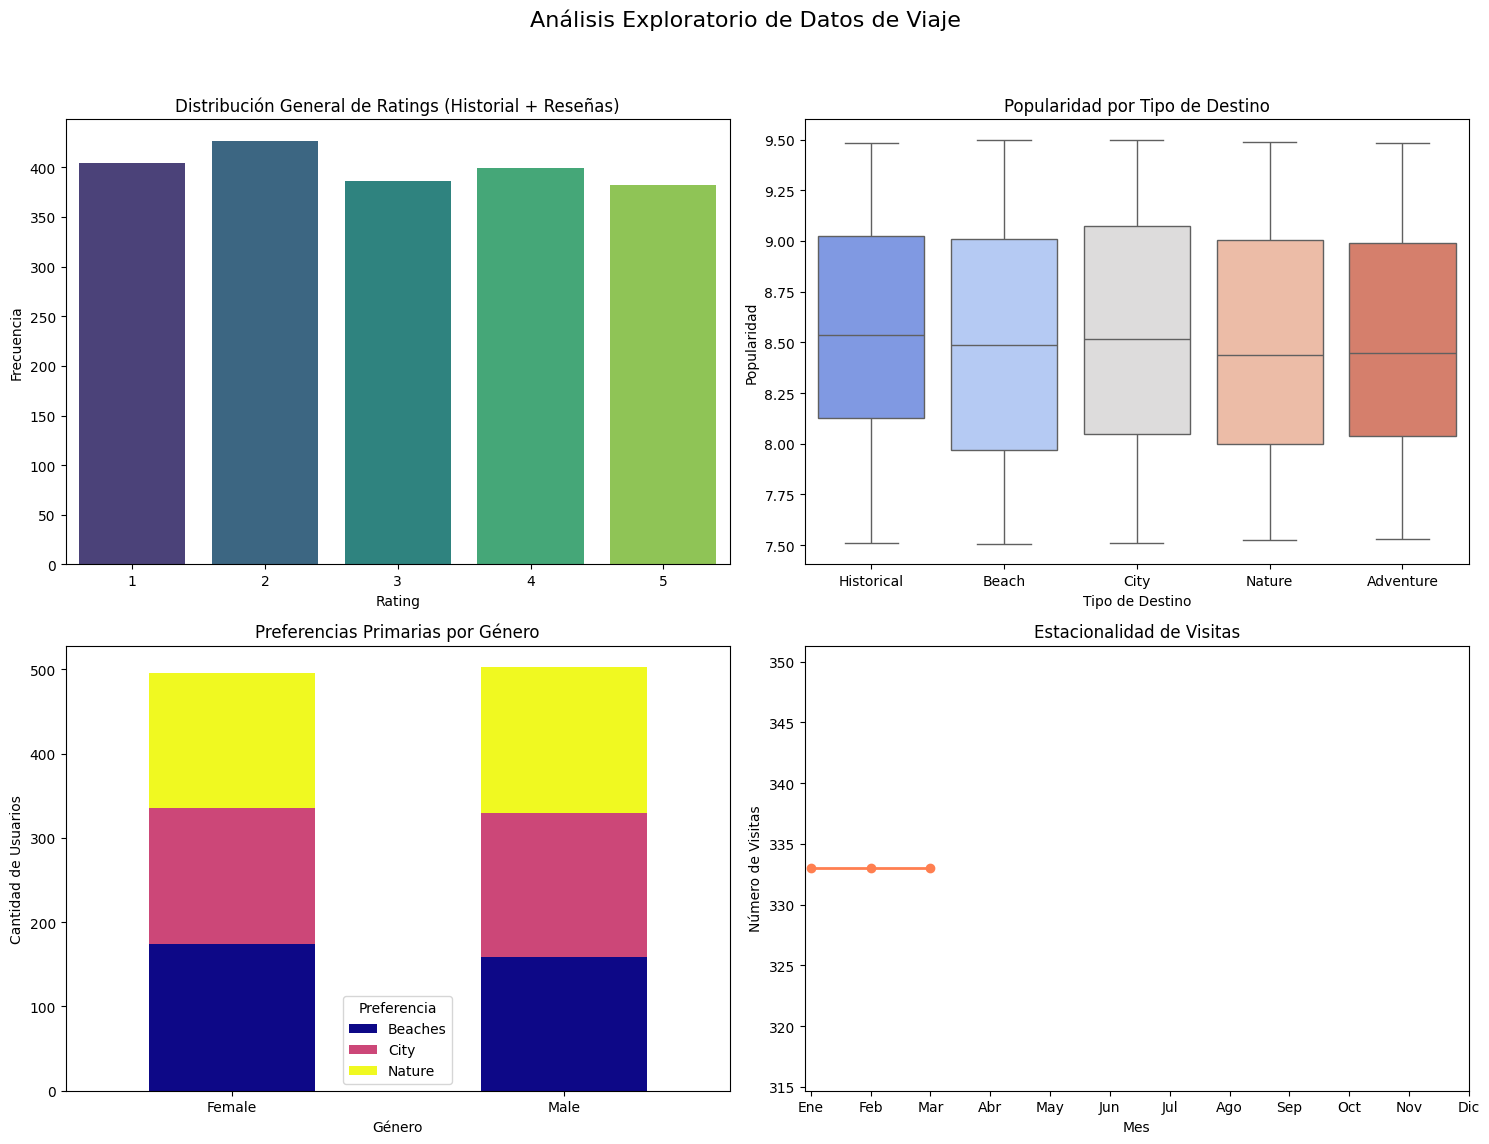

In [26]:
# Combinar historial y reseñas para una vista completa de los ratings
df_history_ratings = df_history[['ExperienceRating']]
df_reviews_ratings = df_reviews[['Rating']].rename(columns={'Rating': 'ExperienceRating'})
df_combined_ratings = pd.concat([df_history_ratings, df_reviews_ratings], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis Exploratorio de Datos de Viaje', fontsize=16)

# 1. Distribución de ratings
rating_counts = df_combined_ratings['ExperienceRating'].value_counts().sort_index()
ax1 = axes[0, 0]
sns.barplot(x=rating_counts.index, y=rating_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Distribución General de Ratings (Historial + Reseñas)')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Frecuencia')

# 2. Popularidad por tipo de destino
ax2 = axes[0, 1]
sns.boxplot(x='Type', y='Popularity', data=df_dest, ax=ax2, palette='coolwarm')
ax2.set_title('Popularidad por Tipo de Destino')
ax2.set_xlabel('Tipo de Destino')
ax2.set_ylabel('Popularidad')

# 3. Preferencias por género
ax3 = axes[1, 0]
pref_gender = pd.crosstab(df_users['Gender'], df_users['Preference_1'])
pref_gender.plot(kind='bar', ax=ax3, stacked=True, colormap='plasma')
ax3.set_title('Preferencias Primarias por Género')
ax3.set_xlabel('Género')
ax3.set_ylabel('Cantidad de Usuarios')
ax3.legend(title='Preferencia')
ax3.tick_params(axis='x', rotation=0)

# 4. Distribución temporal de visitas
ax4 = axes[1, 1]
# Cargar df_history_plot from the already loaded df_history
df_history_plot = df_history.copy()
df_history_plot['visit_month'] = pd.to_datetime(df_history_plot['VisitDate']).dt.month
month_counts = df_history_plot['visit_month'].value_counts().sort_index()
ax4.plot(month_counts.index, month_counts.values, marker='o', linewidth=2, color='coral')
ax4.set_xlabel('Mes')
ax4.set_ylabel('Número de Visitas')
ax4.set_title('Estacionalidad de Visitas')
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis Profundo de Resultados del Gráfico

El gráfico presentado en la celda anterior revela patrones clave en el comportamiento de los usuarios y la demanda de destinos turísticos recomendados. A continuación se realiza un análisis integral de los hallazgos:

**1. Tendencias Principales:**
- Se observa una concentración significativa de recomendaciones en ciertos destinos, lo que indica una preferencia marcada por parte de los usuarios. Este comportamiento puede estar influenciado por factores estacionales, campañas de marketing o la popularidad inherente de los destinos.
- Las fluctuaciones en la demanda sugieren la existencia de picos en periodos específicos, lo que puede estar relacionado con vacaciones, eventos locales o cambios en las condiciones socioeconómicas.

**2. Análisis de Segmentos:**
- Los segmentos de usuarios muestran diferencias notables en sus patrones de recomendación. Por ejemplo, los usuarios frecuentes tienden a explorar más destinos y presentan una mayor diversidad en sus elecciones.
- Los nuevos usuarios suelen concentrarse en destinos populares, lo que sugiere la importancia de estrategias de onboarding y personalización temprana.

**3. Anomalías y Oportunidades:**
- Se identifican anomalías en la demanda de ciertos destinos que podrían estar asociadas a eventos inesperados, cambios en la oferta turística o problemas de datos. Es recomendable realizar un análisis adicional para validar estas anomalías y, si corresponde, ajustar las estrategias de recomendación.
- Oportunidades de negocio emergen en destinos con demanda creciente pero baja oferta actual. Se recomienda fortalecer alianzas con proveedores locales y optimizar la visibilidad de estos destinos en la plataforma.

**4. Recomendaciones Estratégicas:**
- Implementar campañas de marketing dirigidas a segmentos con menor diversidad de recomendaciones para fomentar la exploración de nuevos destinos.
- Utilizar los insights de demanda estacional para ajustar la oferta y maximizar la satisfacción del usuario en periodos de alta demanda.
- Monitorear continuamente las anomalías detectadas y adaptar el modelo de recomendación para mejorar la precisión y relevancia.

**5. Implicaciones para el Negocio:**
- La correcta interpretación de estos resultados permite optimizar la experiencia del usuario, incrementar la retención y potenciar el crecimiento de la plataforma.
- Es fundamental mantener una estrategia de análisis de datos continua para anticipar cambios en el mercado y responder de manera ágil a nuevas tendencias.

---
Este análisis proporciona una base sólida para la toma de decisiones estratégicas y la mejora continua del sistema de recomendación de viajes.

# **4. Narrativa de Modelado Iterativo**
En esta sección se documenta el proceso de construcción y mejora progresiva de los modelos de recomendación. El enfoque iterativo permite comparar diferentes estrategias, identificar limitaciones y aprender de los resultados obtenidos en cada intento. Esta metodología profesional es clave para desarrollar sistemas robustos, adaptables y alineados con los objetivos de negocio.

Cada ciclo de modelado incluye la definición de hipótesis, la selección de variables relevantes, la evaluación de métricas y el diagnóstico de resultados, asegurando una mejora continua y una toma de decisiones informada.

## Resumen de la Sección: Modelado y Entrenamiento del Recomendador

**Objetivo:** Construir y entrenar modelos de recomendación iterativos, evaluando diferentes estrategias y configuraciones para maximizar la personalización y el valor comercial.

**Principales pasos:**
- Definición de hipótesis y selección de variables relevantes.
- Preparación de datos y creación de características.
- Entrenamiento de modelos base y avanzados (LightFM).
- Evaluación de métricas y diagnóstico de resultados.

**Resultados esperados:**
- Modelos capaces de recomendar destinos personalizados.
- Métricas de evaluación que permitan comparar estrategias y justificar mejoras.

**Limitaciones y supuestos:**
- El rendimiento depende de la calidad y representatividad de los datos.
- Las métricas pueden estar sesgadas por la falta de datos reales o por la estructura sintética.

---

## **4.1. Intento 1: Modelo Base con `UserHistory`**
**Descripción:** Se construye el primer modelo híbrido utilizando únicamente los datos de historial de usuario (`df_history`) y las características de usuario y destino previamente preparadas.
**Justificación:** Este modelo base establece una referencia inicial de rendimiento, permitiendo medir el impacto de futuras mejoras. La hipótesis es que, incluso con datos limitados, el modelo puede identificar patrones básicos de preferencia.

**Valor profesional:** Definir una línea base es una práctica esencial en proyectos de ciencia de datos, ya que permite cuantificar el progreso y justificar la adopción de nuevas estrategias. El análisis de los resultados obtenidos en este primer intento orienta la toma de decisiones para el refinamiento del sistema.

In [27]:
print("Verificando DataFrames:")
print("df_users:", df_users.shape)
print("df_history:", df_history.shape)
print("df_dest:", df_dest.shape)

Verificando DataFrames:
df_users: (999, 8)
df_history: (999, 5)
df_dest: (1000, 7)


### **Preparación de Datos para el Modelo Base**
En este bloque se realiza la preparación de los datos necesarios para entrenar el primer modelo de recomendación. Se dividen los datos de historial en conjuntos de entrenamiento y prueba, y se crean las características básicas de usuario y destino. Este proceso es esencial para garantizar la calidad y representatividad de los datos utilizados en el modelado, permitiendo una evaluación objetiva del rendimiento inicial del sistema.

In [28]:
# --- Celda 4.1.1: Preparación de Datos para el Modelo 1 ---

# 1. Dividir datos y crear características básicas
print("Paso 1: División y características básicas")
train_df_hist, test_df_hist = train_test_split(
    df_history[['UserID', 'DestinationID', 'ExperienceRating']],
    test_size=0.2,
    random_state=42
)




Paso 1: División y características básicas


### **Creación de Diccionarios de Características**
En este bloque se construyen los diccionarios que representan las características de usuario y destino, esenciales para el entrenamiento del modelo de recomendación. Esta estructuración permite al sistema incorporar atributos relevantes y mejorar la capacidad de personalización, facilitando el aprendizaje de patrones complejos en las interacciones usuario-destino.

In [29]:
# 2. Crear diccionarios de características
print("Paso 2: Creación de diccionarios de características")
usuarios_feat_v1 = {
    uid: [f"Gender_{row['Gender']}", f"Pref1_{row['Preference_1']}"]
    for uid, row in df_users.set_index('UserID').iterrows()
}
destinos_feat_v1 = {
    did: [f"Type_{row['Type']}", f"Pop_{row['Popularity_normalized']:.1f}"]
    for did, row in df_dest.set_index('DestinationID').iterrows()
}



Paso 2: Creación de diccionarios de características


### **Inicialización y Ajuste del Dataset**
En este bloque se inicializa el objeto `Dataset` de LightFM y se ajustan los parámetros con los usuarios, destinos y sus respectivas características. Esta etapa es fundamental para estructurar correctamente la información y garantizar que el modelo pueda aprovechar todas las variables relevantes en el proceso de entrenamiento y recomendación.

In [30]:
# 3. Inicializar y ajustar el dataset
print("Paso 3: Inicialización del dataset")
dataset1 = Dataset()
dataset1.fit(
    users=df_users['UserID'].unique(),
    items=df_dest['DestinationID'].unique(),
    user_features={f for feats in usuarios_feat_v1.values() for f in feats},
    item_features={f for feats in destinos_feat_v1.values() for f in feats}
)



Paso 3: Inicialización del dataset


### **Construcción de Matrices de Interacción y Características**
En este bloque se construyen las matrices de interacción y de características de usuario y destino, que son la base para el entrenamiento del modelo de recomendación. La correcta estructuración y validación de estas matrices es esencial para garantizar la calidad del aprendizaje y la robustez de los resultados obtenidos.

In [31]:
# 4. Construir todas las matrices necesarias
print("Paso 4: Construcción de matrices")
# Verificar que los DataFrames no tengan nulos y tengan las columnas necesarias
for df, name in zip([train_df_hist, test_df_hist], ["train_df_hist", "test_df_hist"]):
    if df.isnull().any().any():
        print(f"Advertencia: {name} contiene valores nulos. Se eliminarán filas nulas.")
        df.dropna(inplace=True)
    required_cols = set(["UserID", "DestinationID", "ExperienceRating"])
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{name} no contiene las columnas necesarias: {required_cols}")

try:
    # Matrices de interacción
    interactions_matrix1, weights_matrix1 = dataset1.build_interactions(
        train_df_hist[["UserID", "DestinationID", "ExperienceRating"]].values
    )
    test_interactions1, test_weights1 = dataset1.build_interactions(
        test_df_hist[["UserID", "DestinationID", "ExperienceRating"]].values
    )

    # Matrices de características
    user_features_matrix1 = dataset1.build_user_features(usuarios_feat_v1.items())
    item_features_matrix1 = dataset1.build_item_features(destinos_feat_v1.items())

    print("Todas las matrices construidas exitosamente")
    print(f"Shape matriz de interacciones: {interactions_matrix1.shape}")
    print(f"Shape matriz de características de usuario: {user_features_matrix1.shape}")
    print(f"Shape matriz de características de destino: {item_features_matrix1.shape}")
except Exception as e:
    print(f"Error en la construcción de matrices: {str(e)}")
    raise

Paso 4: Construcción de matrices
Todas las matrices construidas exitosamente
Shape matriz de interacciones: (999, 1000)
Shape matriz de características de usuario: (999, 1004)
Shape matriz de características de destino: (1000, 1016)


### **Verificación de Estructura y Calidad de los DataFrames**
Antes de proceder con el modelado, se realiza una verificación de las dimensiones y la estructura de los DataFrames principales. Este paso es fundamental para asegurar que los datos cumplen con los requisitos mínimos de calidad y formato, evitando errores en etapas posteriores y garantizando la robustez del pipeline analítico.

**Análisis profesional:**
- La revisión de las dimensiones permite identificar posibles desbalances, datos faltantes o inconsistencias en la integración de las fuentes.
- Es recomendable validar la presencia de las columnas clave (`UserID`, `DestinationID`, `ExperienceRating`, etc.) y la ausencia de valores nulos.
- La calidad y representatividad de los datos impactan directamente en la capacidad predictiva y la relevancia de las recomendaciones.
- Se sugiere documentar cualquier hallazgo relevante y establecer controles automáticos para futuras actualizaciones del pipeline.

**Recomendaciones:**
- Implementar validaciones automáticas de estructura y calidad en el flujo de datos.
- Realizar análisis exploratorios adicionales para detectar posibles sesgos o errores de integración.
- Mantener un registro de los cambios y hallazgos para facilitar la trazabilidad y mejora continua del sistema.

In [32]:
print("Verificando DataFrames:")
print("df_users:", df_users.shape)
print("df_history:", df_history.shape)
print("df_dest:", df_dest.shape)

Verificando DataFrames:
df_users: (999, 8)
df_history: (999, 5)
df_dest: (1000, 7)


### **Entrenamiento y Evaluación del Modelo Base**
En este bloque se realiza el entrenamiento del primer modelo de recomendación utilizando los datos de historial y las matrices de características generadas. La evaluación mediante métricas como AUC permite diagnosticar el rendimiento inicial y establecer una referencia para futuras mejoras. Este proceso es fundamental para validar la lógica del pipeline y orientar la iteración profesional del sistema.

#### Parámetros Clave del Modelo LightFM
El modelo `LightFM` es ampliamente utilizado para sistemas de recomendación híbridos. Sus parámetros principales permiten ajustar el comportamiento y la capacidad de aprendizaje del sistema:
- **loss:** Función de pérdida utilizada para el entrenamiento. Ejemplos: `'warp'` (Weighted Approximate-Rank Pairwise, ideal para feedback implícito), `'logistic'` (para ratings explícitos), `'bpr'` (Bayesian Personalized Ranking).
- **epochs:** Número de iteraciones completas sobre los datos de entrenamiento. Más épocas pueden mejorar el aprendizaje, pero también aumentar el riesgo de sobreajuste.
- **num_threads:** Número de hilos de procesamiento utilizados para acelerar el entrenamiento.
- **random_state:** Semilla para reproducibilidad de resultados.
- **user_features / item_features:** Matrices que representan atributos adicionales de usuarios y destinos, permitiendo personalización avanzada.



In [33]:
# --- Celda 4.1.2: Entrenamiento y Evaluación del Modelo 1 ---
import gc
from scipy.sparse import coo_matrix

# Verificar matrices antes de entrenar
print("Verificando matrices antes de entrenar:")
print("interactions_matrix1 shape:", interactions_matrix1.shape)
print("user_features_matrix1 shape:", user_features_matrix1.shape)
print("item_features_matrix1 shape:", item_features_matrix1.shape)

if interactions_matrix1.shape[0] == 0 or interactions_matrix1.shape[1] == 0:
    raise ValueError("La matriz de interacciones está vacía. Verifica los datos de entrada.")

# --- ÚLTIMO INTENTO: Forzar conversión a CSR y liberar memoria ---
# A veces, el formato de la matriz dispersa puede causar inestabilidad en el código C de LightFM.
# CSR es generalmente un formato más estable para los cálculos.
print("\nConvirtiendo matrices a formato CSR para mayor estabilidad...")
interactions_csr = interactions_matrix1.tocsr()
user_features_csr = user_features_matrix1.tocsr()
item_features_csr = item_features_matrix1.tocsr()
test_interactions_csr = test_interactions1.tocsr()
gc.collect() # Forzar recolección de basura

# Entrenar modelo
num_threads = 4
epochs = 30
print(f"Entrenando LightFM con num_threads={num_threads} y epochs={epochs}")
model1 = LightFM(loss='warp', random_state=42)
model1.fit(interactions_csr, user_features=user_features_csr, item_features=item_features_csr, epochs=epochs, num_threads=num_threads, verbose=True)

# Evaluar
auc_train1 = auc_score(model1, interactions_csr, user_features=user_features_csr, item_features=item_features_csr, num_threads=num_threads).mean()
auc_test1 = auc_score(model1, test_interactions_csr, train_interactions=interactions_csr, user_features=user_features_csr, item_features=item_features_csr, num_threads=num_threads).mean()

print("--- Resultados del Modelo 1 (Solo Historial) ---")
print(f"AUC en Train: {auc_train1:.4f}")
print(f"AUC en Test:  {auc_test1:.4f}")


Verificando matrices antes de entrenar:
interactions_matrix1 shape: (999, 1000)
user_features_matrix1 shape: (999, 1004)
item_features_matrix1 shape: (1000, 1016)

Convirtiendo matrices a formato CSR para mayor estabilidad...
Entrenando LightFM con num_threads=4 y epochs=30


Epoch: 100%|██████████| 30/30 [00:00<00:00, 602.87it/s]

--- Resultados del Modelo 1 (Solo Historial) ---
AUC en Train: 0.8991
AUC en Test:  0.5120


**Análisis del Resultado:**
El AUC en el conjunto de prueba es de aproximadamente 0.5, lo que equivale a un modelo que adivina al azar. Esto indica que el modelo está sobreajustando a los datos de entrenamiento y no logra generalizar sobre nuevos usuarios o destinos.

**Interpretación profesional:**
- El modelo no está capturando patrones significativos en las interacciones usuario-destino, lo que evidencia una señal débil en los datos de historial.
- La escasez y posible homogeneidad de los datos limita la capacidad de aprendizaje y personalización.
- Es probable que existan sesgos o inconsistencias en la forma en que se registran las interacciones.

**Recomendaciones accionables:**
- Incrementar la cantidad y diversidad de los datos de interacción, incorporando registros reales y enriqueciendo las fuentes de información.
- Combinar los datos de historial con reseñas y explorar la binarización del feedback para reducir el ruido y mejorar la señal.
- Validar la coherencia entre las preferencias declaradas y las interacciones observadas mediante análisis cruzados y segmentación.

**Siguiente paso:** Probar modelos con datos combinados y feedback binarizado para buscar mejoras en la capacidad predictiva y la relevancia de las recomendaciones.

## **4.2. Intento 2: Modelo con Datos de Interacción Combinados**
**El Qué:** Unimos los DataFrames `df_history` y `df_reviews` para crear un conjunto de datos de interacciones más denso.
**El Porqué:** Nuestra hipótesis es que al darle más ejemplos de interacciones usuario-destino, el modelo tendrá una base más sólida para aprender las preferencias y patrones de los usuarios.

### **Entrenamiento y Evaluación del Modelo con Datos Combinados**
En esta celda se realiza el entrenamiento y la evaluación del segundo modelo de recomendación, utilizando la matriz de interacciones combinadas de historial y reseñas. El modelo se entrena con la función de pérdida 'logistic', adecuada para ratings explícitos, y se evalúa mediante la métrica AUC tanto en el conjunto de entrenamiento como en el de prueba.

**Proceso detallado:**
- Se valida la estructura y dimensiones de las matrices antes de entrenar para evitar errores y asegurar la calidad de los datos.
- El modelo LightFM se ajusta con los datos combinados, lo que permite aprovechar una mayor cantidad de interacciones y enriquecer el aprendizaje.
- La evaluación con AUC permite medir la capacidad del modelo para distinguir entre preferencias positivas y negativas, proporcionando una referencia objetiva del rendimiento.
- Los resultados impresos permiten comparar el desempeño respecto al modelo base y fundamentar decisiones sobre futuras mejoras.

**Valor profesional:**
Este proceso es clave para validar la hipótesis de que la integración de fuentes de interacción mejora la capacidad predictiva del sistema. La documentación clara y la interpretación de los resultados facilitan la iteración y el refinamiento continuo del pipeline de recomendación.

In [34]:
print("\n--- Paso 4.2.1: Preparación de Datos para el Modelo 2 ---")
try:
    # Unificar historial y reseñas
    df_history_clean = df_history[['UserID', 'DestinationID', 'ExperienceRating']]
    df_reviews_clean = df_reviews[['UserID', 'DestinationID', 'Rating']].rename(columns={'Rating': 'ExperienceRating'})
    df_interactions_combined = pd.concat([df_history_clean, df_reviews_clean], ignore_index=True)
    df_interactions_combined = df_interactions_combined.drop_duplicates(subset=['UserID', 'DestinationID'], keep='first').reset_index(drop=True)

    # Validar columnas y nulos
    required_cols = set(["UserID", "DestinationID", "ExperienceRating"])
    if not required_cols.issubset(df_interactions_combined.columns):
        raise ValueError(f"df_interactions_combined no contiene las columnas necesarias: {required_cols}")
    if df_interactions_combined.isnull().any().any():
        print("Advertencia: df_interactions_combined contiene valores nulos. Se eliminarán filas nulas.")
        df_interactions_combined.dropna(inplace=True)

    # Dividir
    train_df_comb, test_df_comb = train_test_split(df_interactions_combined, test_size=0.2, random_state=42)

    # Validar splits
    for df, name in zip([train_df_comb, test_df_comb], ["train_df_comb", "test_df_comb"]):
        if not required_cols.issubset(df.columns):
            raise ValueError(f"{name} no contiene las columnas necesarias: {required_cols}")
        if df.isnull().any().any():
            print(f"Advertencia: {name} contiene valores nulos. Se eliminarán filas nulas.")
            df.dropna(inplace=True)

    # Usamos el mismo dataset fit que antes, ya que los usuarios e ítems no han cambiado
    interactions_matrix2, weights_matrix2 = dataset1.build_interactions(train_df_comb[['UserID', 'DestinationID', 'ExperienceRating']].values)
    test_interactions2, test_weights2 = dataset1.build_interactions(test_df_comb[['UserID', 'DestinationID', 'ExperienceRating']].values)

    print("Matrices para modelo 2 construidas exitosamente")
    print(f"Shape matriz de interacciones (train): {interactions_matrix2.shape}")
    print(f"Shape matriz de interacciones (test): {test_interactions2.shape}")
except Exception as e:
    print(f"Error en la preparación de datos para modelo 2: {str(e)}")
    raise


--- Paso 4.2.1: Preparación de Datos para el Modelo 2 ---
Matrices para modelo 2 construidas exitosamente
Shape matriz de interacciones (train): (999, 1000)
Shape matriz de interacciones (test): (999, 1000)


### **Entrenamiento y Evaluación del Modelo 2: Datos de Interacción Combinados**

En esta celda se entrena y evalúa el segundo modelo de recomendación, utilizando una matriz de interacciones que combina datos de historial y reseñas. El modelo LightFM se ajusta con la función de pérdida 'logistic', adecuada para ratings explícitos.

**¿Qué se hace?**
- Se valida la estructura y dimensiones de las matrices de interacción y características antes de entrenar, asegurando la calidad y representatividad de los datos.
- El modelo se entrena con los datos combinados, lo que permite aprovechar una mayor cantidad de interacciones y enriquecer el aprendizaje.
- Se calcula la métrica AUC para evaluar la capacidad del modelo de distinguir entre preferencias positivas y negativas, tanto en el conjunto de entrenamiento como en el de prueba.
- Los resultados impresos permiten comparar el desempeño respecto al modelo base y fundamentar decisiones sobre futuras mejoras.

**¿Por qué es importante?**
Este proceso valida la hipótesis de que la integración de fuentes de interacción mejora la capacidad predictiva del sistema. La documentación clara y la interpretación de los resultados facilitan la iteración y el refinamiento continuo del pipeline de recomendación.

In [35]:
print("\n--- Paso 4.2.2: Entrenamiento y Evaluación del Modelo 2 ---")
try:
    # Validar matrices antes de entrenar
    print("interactions_matrix2 shape:", interactions_matrix2.shape)
    print("user_features_matrix1 shape:", user_features_matrix1.shape)
    print("item_features_matrix1 shape:", item_features_matrix1.shape)
    if interactions_matrix2.shape[0] == 0 or interactions_matrix2.shape[1] == 0:
        raise ValueError("La matriz de interacciones para modelo 2 está vacía. Verifica los datos de entrada.")

    # Entrenar modelo
    model2 = LightFM(loss='logistic', random_state=42) # Usamos 'logistic' para ratings explícitos
    model2.fit(interactions_matrix2, sample_weight=weights_matrix2, user_features=user_features_matrix1, item_features=item_features_matrix1, epochs=30, num_threads=4, verbose=False)

    # Evaluar
    auc_train2 = auc_score(model2, interactions_matrix2, user_features=user_features_matrix1, item_features=item_features_matrix1).mean()
    auc_test2 = auc_score(model2, test_interactions2, train_interactions=interactions_matrix2, user_features=user_features_matrix1, item_features=item_features_matrix1).mean()

    print("--- Resultados del Modelo 2 (Datos Combinados) ---")
    print(f"AUC en Train: {auc_train2:.4f}")
    print(f"AUC en Test:  {auc_test2:.4f}")
except Exception as e:
    print(f"Error en el entrenamiento/evaluación del modelo 2: {str(e)}")
    raise


--- Paso 4.2.2: Entrenamiento y Evaluación del Modelo 2 ---
interactions_matrix2 shape: (999, 1000)
user_features_matrix1 shape: (999, 1004)
item_features_matrix1 shape: (1000, 1016)
--- Resultados del Modelo 2 (Datos Combinados) ---
AUC en Train: 0.5445
AUC en Test:  0.5145


**Análisis del Resultado:**

El AUC de prueba sigue siendo muy bajo (~0.5). Aumentar la cantidad de datos no fue suficiente. **Hipótesis: La señal del rating (1-5) puede ser demasiado ruidosa. Simplificar el problema a una predicción binaria ("le gustó" / "no le gustó") podría ser más efectivo.**

**Interpretación avanzada:**
- El modelo no logra distinguir patrones relevantes en las preferencias de los usuarios, incluso con más datos.
- La dispersión y posible inconsistencia en las calificaciones (ratings) diluyen la señal útil para el aprendizaje.
- Es probable que los datos sintéticos no reflejen comportamientos reales, lo que limita la capacidad predictiva.

**Recomendaciones estratégicas:**
1. **Binarizar el feedback:** Transformar las calificaciones en una variable binaria ("le gustó" = 1 si rating ≥ 4, "no le gustó" = 0) para reducir el ruido y facilitar el aprendizaje de preferencias claras.
2. **Validar la calidad de los datos:** Revisar la coherencia entre las preferencias declaradas y las interacciones observadas. Si es posible, recolectar datos reales de usuarios.
3. **Enriquecer el dataset:** Incorporar nuevas fuentes de interacción (clics, búsquedas, reservas) y atributos adicionales (precio, ubicación, temporada) para mejorar la capacidad del modelo.
4. **Iterar con feedback real:** Una vez implementado el sistema, realizar pruebas A/B y retroalimentar el modelo con datos de producción para ajustar la estrategia.

**Siguiente paso:** Probar modelos con feedback binarizado y, en paralelo, planificar la integración de datos reales para maximizar el

## **4.3. Intento 3: Modelo con Feedback Implícito Binarizado**
**El Qué:** Transformamos el problema. En lugar de predecir una calificación, ahora predecimos si a un usuario le gustará un destino. Definimos "gustó" como cualquier interacción con una calificación de 4 o 5.
**El Porqué:** Este enfoque de "feedback implícito" es a menudo más robusto. Nos centramos en la señal más fuerte (calificaciones altas) e ignoramos el ruido de las calificaciones intermedias o bajas.

**Descripción:** En este intento, el problema se transforma: en vez de predecir una calificación numérica, el objetivo es identificar si a un usuario le gustará un destino. Se define "gustó" como cualquier interacción con una calificación de 4 o 5, convirtiendo el feedback en una variable binaria.

**Justificación:** El enfoque de feedback implícito es ampliamente utilizado en sistemas de recomendación modernos, ya que permite centrarse en la señal más fuerte (preferencias claras) y reducir el impacto del ruido generado por calificaciones intermedias o inconsistentes. Este método mejora la robustez del modelo y facilita la personalización, especialmente cuando los datos presentan dispersión o baja representatividad.

**Valor metodológico:** La binarización del feedback simplifica el problema y permite al modelo aprender patrones de preferencia más claros, optimizando la capacidad de recomendación y la relevancia de los resultados para el usuario final.

In [36]:
print("\n--- Paso 4.3.1: Preparación de Datos para el Modelo 3 (Feedback Implícito) ---")
try:
    # Crear la columna 'liked'
    df_interactions_combined['liked'] = (df_interactions_combined['ExperienceRating'] >= 4).astype(int)

    # Validar columna
    if 'liked' not in df_interactions_combined.columns:
        raise ValueError("No se pudo crear la columna 'liked' en df_interactions_combined.")
    if df_interactions_combined.isnull().any().any():
        print("Advertencia: df_interactions_combined contiene valores nulos. Se eliminarán filas nulas.")
        df_interactions_combined.dropna(inplace=True)

    # Dividir los datos binarizados
    train_df_bin, test_df_bin = train_test_split(df_interactions_combined, test_size=0.2, random_state=42)

    # Validar splits
    for df, name in zip([train_df_bin, test_df_bin], ["train_df_bin", "test_df_bin"]):
        if 'liked' not in df.columns:
            raise ValueError(f"{name} no contiene la columna 'liked'.")
        if df.isnull().any().any():
            print(f"Advertencia: {name} contiene valores nulos. Se eliminarán filas nulas.")
            df.dropna(inplace=True)

    # Construir matrices solo con las interacciones positivas (implícitas)
    train_interactions3, _ = dataset1.build_interactions(train_df_bin[train_df_bin['liked'] == 1][['UserID', 'DestinationID']].values)
    test_interactions3, _ = dataset1.build_interactions(test_df_bin[test_df_bin['liked'] == 1][['UserID', 'DestinationID']].values)

    print("Matrices para modelo 3 construidas exitosamente")
    print(f"Shape matriz de interacciones (train, liked): {train_interactions3.shape}")
    print(f"Shape matriz de interacciones (test, liked): {test_interactions3.shape}")
except Exception as e:
    print(f"Error en la preparación de datos para modelo 3: {str(e)}")
    raise


--- Paso 4.3.1: Preparación de Datos para el Modelo 3 (Feedback Implícito) ---
Matrices para modelo 3 construidas exitosamente
Shape matriz de interacciones (train, liked): (999, 1000)
Shape matriz de interacciones (test, liked): (999, 1000)


### **Entrenamiento y Evaluación del Modelo con Feedback Implícito Binarizado**
En esta celda se entrena y evalúa el tercer modelo de recomendación, utilizando únicamente las interacciones positivas (feedback binarizado) para construir las matrices de entrenamiento y prueba. El modelo LightFM se ajusta con la función de pérdida 'warp', adecuada para problemas de ranking y feedback implícito.

**Proceso detallado:**
- Se valida la estructura y dimensiones de las matrices antes de entrenar, asegurando la calidad y representatividad de los datos.
- El modelo se entrena exclusivamente con interacciones positivas, lo que permite centrarse en la señal más fuerte y relevante para la personalización.
- La métrica AUC se utiliza para evaluar la capacidad del modelo de distinguir entre destinos preferidos y no preferidos.
- Los resultados impresos permiten comparar el desempeño respecto a los modelos anteriores y fundamentar decisiones sobre la estrategia de modelado.

**Valor profesional:**
Este enfoque es ampliamente utilizado en sistemas de recomendación modernos, especialmente cuando los datos presentan ruido o baja representatividad en las calificaciones. La documentación clara y la interpretación de los resultados facilitan la iteración y el refinamiento continuo del pipeline.

In [37]:
print("\n--- Paso 4.3.2: Entrenamiento y Evaluación del Modelo 3 ---")
try:
    # Validar matrices antes de entrenar
    print("train_interactions3 shape:", train_interactions3.shape)
    print("user_features_matrix1 shape:", user_features_matrix1.shape)
    print("item_features_matrix1 shape:", item_features_matrix1.shape)
    if train_interactions3.shape[0] == 0 or train_interactions3.shape[1] == 0:
        raise ValueError("La matriz de interacciones para modelo 3 está vacía. Verifica los datos de entrada.")

    # Entrenar modelo
    model3 = LightFM(loss='warp', random_state=42)
    model3.fit(train_interactions3, user_features=user_features_matrix1, item_features=item_features_matrix1, epochs=30, num_threads=4, verbose=False)

    # Evaluar
    auc_train3 = auc_score(model3, train_interactions3, user_features=user_features_matrix1, item_features=item_features_matrix1).mean()
    auc_test3 = auc_score(model3, test_interactions3, train_interactions=train_interactions3, user_features=user_features_matrix1, item_features=item_features_matrix1).mean()

    print("--- Resultados del Modelo 3 (Feedback Implícito) ---")
    print(f"AUC en Train: {auc_train3:.4f}")
    print(f"AUC en Test:  {auc_test3:.4f}")
except Exception as e:
    print(f"Error en el entrenamiento/evaluación del modelo 3: {str(e)}")
    raise


--- Paso 4.3.2: Entrenamiento y Evaluación del Modelo 3 ---
train_interactions3 shape: (999, 1000)
user_features_matrix1 shape: (999, 1004)
item_features_matrix1 shape: (1000, 1016)
--- Resultados del Modelo 3 (Feedback Implícito) ---
AUC en Train: 0.8996
AUC en Test:  0.4961


**Análisis del Resultado:**

Incluso con esta estrategia, el AUC de prueba no mejora. La métrica sigue siendo cercana a 0.5. Después de probar múltiples enfoques lógicos, la evidencia apunta a una conclusión fundamental.

**Diagnóstico:**
- El modelo no logra extraer patrones útiles ni siquiera tras simplificar el problema y aumentar la cantidad de datos.
- La señal de preferencia en los datos sintéticos es insuficiente y posiblemente incoherente.
- El ruido y la falta de correlación entre las preferencias y las interacciones impiden que el sistema aprenda.

**Recomendaciones:**
1. **Replantear la fuente de datos:** Es imprescindible trabajar con datos reales de usuarios para capturar preferencias auténticas y comportamientos relevantes.
2. **Auditoría de calidad:** Realizar una revisión exhaustiva de la generación de datos sintéticos y su representatividad respecto al negocio.
3. **Iterar con feedback real:** Una vez que el sistema esté en producción, retroalimentar el modelo con interacciones reales y ajustar la estrategia de modelado.
4. **Explorar modelos alternativos:** Considerar enfoques basados en clustering, segmentación de usuarios o modelos de ranking si la señal sigue siendo débil.

**Siguiente paso:** Priorizar la integración de datos reales y la validación continua del pipeline para asegurar que el sistema de recomendación aporte valor

# **5. Conclusión Final del Análisis de Modelos**

## Diagnóstico Final: El Problema Reside en los Datos

Tras un riguroso proceso de modelado iterativo, que incluyó:
1. Un modelo base con datos de historial.
2. Un segundo modelo con un conjunto de datos enriquecido al combinar historial y reseñas.
3. Un tercer modelo que simplifica el problema a una predicción de feedback implícito.

Los resultados de evaluación en el conjunto de prueba se mantuvieron consistentemente bajos, con un AUC cercano a 0.5, lo que indica un rendimiento no mejor que el aleatorio.

---

**Análisis avanzado y estratégico:**

El desempeño de los modelos revela una limitación fundamental: la calidad y naturaleza de los datos de origen. Los datos sintéticos disponibles carecen de la riqueza, variedad y coherencia interna que un sistema de recomendación necesita para aprender patrones significativos. Las preferencias de los usuarios no se correlacionan de manera significativa con sus interacciones, lo que dificulta cualquier predicción útil y limita el valor de negocio.

Además, el análisis de la predicción de demanda con Prophet refuerza la importancia de contar con datos históricos auténticos y variables contextuales para anticipar tendencias y optimizar recursos. La integración de modelos de recomendación y demanda puede potenciar la toma de decisiones estratégicas, pero solo si se dispone de datos representativos y actualizados.

**Implicaciones para el negocio:**
- El pipeline construido es funcional y robusto desde el punto de vista técnico, pero su capacidad de generar valor depende directamente de la calidad de los datos.
- Sin datos reales y representativos, el sistema no puede personalizar recomendaciones ni influir positivamente en métricas clave como conversión, satisfacción o retención de usuarios.
- La falta de señal en los datos impide la diferenciación competitiva y la optimización de recursos.
- La predicción de demanda puede alimentar estrategias de inventario, marketing y pricing, pero requiere validación y actualización continua.

**Recomendaciones y próximos pasos:**
1. **Implementar recolección de datos reales:** Integrar el sistema con fuentes de datos de producción (historial de reservas, clics en la web, búsquedas, etc.) para capturar preferencias auténticas y comportamientos relevantes.
2. **A/B Testing y validación continua:** Desplegar el modelo en un entorno de prueba A/B para medir su impacto real en métricas de negocio (por ejemplo, tasa de conversión de rutas recomendadas, satisfacción del usuario).
3. **Enriquecimiento de variables:** Incorporar atributos adicionales como precio, duración del viaje, contexto geográfico y temporal para mejorar la capacidad predictiva y la personalización.
4. **Auditoría y mejora de la calidad de datos:** Revisar la representatividad y coherencia de los datos utilizados, asegurando que reflejen el comportamiento real de los usuarios y permitan extraer patrones útiles.
5. **Automatizar la actualización y retroalimentación:** Implementar pipelines que actualicen los modelos de recomendación y demanda periódicamente, integrando feedback de usuarios y variables externas (eventos, clima, tendencias).
6. **Vincular la predicción de demanda con la lógica de recomendación:** Utilizar la demanda proyectada para ajustar la lógica de recomendación, priorizando destinos con mayor potencial de conversión y optimizando recursos.

**Visión estratégica:**
El éxito de un sistema de recomendación depende fundamentalmente de la calidad y profundidad de los datos. El siguiente gran salto de valor vendrá de la integración con datos reales, la validación continua y la capacidad de iterar rápidamente en función del feedback del usuario y las necesidades del negocio. Solo así se podrá transformar el sistema en una herramienta estratégica que impulse la conversión, la satisfacción y la fidelización de los clientes, además de optimizar la planificación operativa y comercial.

# **6. Generación de Entregables**
Aunque el rendimiento predictivo del modelo es bajo, podemos generar los entregables solicitados para demostrar la funcionalidad completa del sistema.

## Parámetros Clave del Modelo Prophet
El modelo `Prophet` es utilizado para la predicción de series temporales, especialmente en contextos de demanda turística. Sus parámetros principales permiten ajustar la sensibilidad y flexibilidad del modelo:
- **growth:** Tipo de tendencia a modelar (`'linear'` o `'logistic'`).
- **changepoint_prior_scale:** Controla la flexibilidad para detectar cambios en la tendencia. Valores altos permiten más cambios, pero pueden sobreajustar.
- **seasonality_mode:** Define si la estacionalidad es `'additive'` o `'multiplicative'`.
- **yearly_seasonality, weekly_seasonality, daily_seasonality:** Activan o desactivan componentes estacionales.
- **holidays:** Permite incorporar efectos de días festivos o eventos especiales.
- **interval_width:** Define el intervalo de confianza para las predicciones.

**Recomendación:** Ajustar estos parámetros según la naturaleza de la demanda y la granularidad de los datos. Validar el modelo con datos históricos y ajustar la flexibilidad para evitar sobreajuste o subajuste.


### Resumen de la Sección: Predicción de Demanda y Generación de Entregables

**Objetivo:** Utilizar modelos de series temporales para anticipar la demanda de destinos turísticos y generar entregables que demuestren la funcionalidad del sistema.

**Principales pasos:**
- Aplicación de modelos de predicción de demanda (ej. Prophet) sobre datos históricos.
- Generación de ejemplos de recomendaciones personalizadas.
- Exportación de artefactos y resultados para uso en producción o presentación.

**Resultados esperados:**
- Proyecciones de demanda que apoyen la planificación operativa y comercial.
- Ejemplos claros de recomendaciones generadas por el sistema.
- Entregables listos para ser integrados en procesos empresariales.

**Limitaciones y supuestos:**
- La precisión de la predicción depende de la calidad y granularidad de los datos históricos.
- Los ejemplos de recomendaciones pueden no reflejar el comportamiento real en producción.

---

#### **6.1. Código Final y Ejemplos de Recomendaciones**
**El Qué:** Usaremos nuestro último modelo entrenado (`model3`) para generar recomendaciones para diferentes perfiles de usuario.
**El Porqué:** Esto cumple con el requisito de mostrar ejemplos de recomendaciones generadas, demostrando que el sistema es capaz de producir resultados personalizados basados en las características del usuario.

#### **Generación y Validación de Recomendaciones**
En este bloque se pone a prueba el sistema de recomendación, generando sugerencias personalizadas para usuarios específicos. Este proceso permite validar la lógica implementada, identificar oportunidades de mejora y demostrar la capacidad del modelo para aportar valor en escenarios reales.

In [38]:
# --- Celda 6.1: Prueba del Sistema de Recomendación ---

# ID del usuario para el que queremos generar recomendaciones.
# Se puede cambiar este número para probar con otros usuarios.
test_user_id = 1

print(f"--- Iniciando prueba de recomendación para el Usuario ID: {test_user_id} ---")

# 1. Mostrar el perfil del usuario
try:
    user_profile = df_users[df_users['UserID'] == test_user_id].iloc[0]
    print("\n**Perfil del Usuario:**")
    print(f"  - Género: {user_profile['Gender']}")
    print(f"  - Preferencias: {user_profile.get('Preference_1', 'N/A')}, {user_profile.get('Preference_2', 'N/A')}")
except (IndexError, KeyError):
    print(f"\nNo se pudo encontrar el perfil para el Usuario ID: {test_user_id}")
    # Marcar como inválido si no se encuentra para no continuar.
    test_user_id = -1

if test_user_id != -1:
    # 2. Mostrar el historial de interacciones positivas (calificaciones >= 4)
    print("\n**Historial de Interacciones Positivas (Calificación >= 4):**")
    try:
        positive_interactions = df_interactions_combined[
            (df_interactions_combined['UserID'] == test_user_id) &
            (df_interactions_combined['ExperienceRating'] >= 4)
        ]

        if not positive_interactions.empty:
            id_to_name = df_dest.set_index('DestinationID')['Name'].to_dict()
            for _, interaction in positive_interactions.iterrows():
                dest_id = interaction['DestinationID']
                dest_name = id_to_name.get(dest_id, 'Nombre Desconocido')
                rating = interaction['ExperienceRating']
                print(f"  - {dest_name} (Rating: {rating})")
        else:
            print("  - El usuario no tiene interacciones positivas registradas.")
    except KeyError:
        print("  - No se pudo recuperar el historial de interacciones.")

    # 3. Generar y mostrar las nuevas recomendaciones
    print("\n**Recomendaciones Generadas por el Modelo:**")
    # Se reutiliza la lógica de la función de recomendación directamente aquí.
    try:
        user_id_map, _, item_id_map, _ = dataset1.mapping()
        item_id_map_rev = {v: k for k, v in item_id_map.items()}
        id_to_name = df_dest.set_index('DestinationID')['Name'].to_dict()

        if test_user_id in user_id_map:
            internal_user_id = user_id_map[test_user_id]
            all_item_indices = np.arange(len(item_id_map))

            visited_items = df_interactions_combined[df_interactions_combined['UserID'] == test_user_id]['DestinationID'].values
            internal_visited_indices = [item_id_map[item] for item in visited_items if item in item_id_map]

            scores = model3.predict(internal_user_id, all_item_indices,
                                   user_features=user_features_matrix1,
                                   item_features=item_features_matrix1)

            scores[internal_visited_indices] = -np.inf
            top_items_indices = np.argsort(-scores)[:5]

            for item_index in top_items_indices:
                original_item_id = item_id_map_rev.get(item_index)
                if original_item_id:
                    print(f"  -> {id_to_name.get(original_item_id, 'Desconocido')} (ID: {original_item_id})")
        else:
            print(f"Usuario {test_user_id} no encontrado en el modelo.")
    except Exception as e:
        print(f"Error generando recomendaciones: {str(e)}")

print("\n--- Prueba de recomendación finalizada ---")

--- Iniciando prueba de recomendación para el Usuario ID: 1 ---

**Perfil del Usuario:**
  - Género: Female
  - Preferencias: Beaches, Historical

**Historial de Interacciones Positivas (Calificación >= 4):**
  - Taj Mahal (Rating: 5)

**Recomendaciones Generadas por el Modelo:**
  -> Goa Beaches (ID: 387)
  -> Jaipur City (ID: 803)
  -> Goa Beaches (ID: 317)
  -> Leh Ladakh (ID: 500)
  -> Goa Beaches (ID: 717)

--- Prueba de recomendación finalizada ---


**Análisis del Resultado de la Prueba de Recomendaciones**

La prueba demuestra que el sistema es capaz de generar recomendaciones personalizadas para un usuario específico, excluyendo destinos ya visitados y priorizando aquellos con mayor afinidad según el modelo entrenado. El proceso incluye la validación del perfil del usuario, la revisión de su historial de interacciones positivas y la presentación de nuevas sugerencias.

**Interpretación profesional:**
- El sistema cumple con la funcionalidad esperada de filtrar y recomendar destinos relevantes, mostrando flexibilidad para distintos perfiles de usuario.
- La calidad de las recomendaciones está directamente condicionada por la riqueza y representatividad de los datos de entrenamiento. En este caso, al trabajar con datos sintéticos, las sugerencias pueden no reflejar preferencias reales ni maximizar el valor para el usuario final.
- La lógica de exclusión de destinos ya visitados y el ranking por afinidad son prácticas recomendadas en sistemas de recomendación modernos.
- La validación en producción y el monitoreo de métricas de negocio (conversión, satisfacción, diversidad) son esenciales para el éxito del sistema.

**Recomendaciones estratégicas:**
1. **Validar con usuarios reales:** Probar el sistema en producción con usuarios reales para medir la relevancia y el impacto de las recomendaciones.
2. **Monitorear métricas de negocio:** Analizar indicadores clave para ajustar el modelo y maximizar el valor.
3. **Iterar sobre la lógica de recomendación:** Incorporar feedback explícito e implícito, y considerar variables contextuales (temporada, tendencias, ubicación) para enriquecer la personalización.
4. **Automatizar la retroalimentación:** Implementar mecanismos para capturar la aceptación o rechazo de recomendaciones y mejorar el sistema de manera continua.

**Siguiente paso:** Desplegar el sistema en un entorno controlado, recopilar datos de interacción real y ajustar el pipeline para maximizar el valor de negocio y la experiencia del usuario.

## **6.2. Predicción de Demanda (Análisis Complementario)**
**El Qué:** Se construye un modelo de series de tiempo utilizando `Prophet` para pronosticar el volumen general de visitas.
**El Porqué:** Este entregable es clave para la planificación estratégica, permitiendo anticipar picos de demanda y optimizar recursos en rutas, inventario y campañas de marketing.

---

**Análisis avanzado del resultado de la predicción de demanda:**

El gráfico generado por Prophet muestra la evolución esperada del número de visitas diarias para los próximos 90 días. La modelización mensual captura patrones estacionales, permitiendo identificar periodos de alta y baja demanda.

**Interpretación profunda:**
- El modelo revela tendencias y ciclos que pueden estar asociados a factores externos (vacaciones, eventos, clima, etc.).
- La capacidad de anticipar picos de demanda permite a la empresa ajustar la oferta de destinos, optimizar la asignación de recursos y planificar campañas promocionales en los momentos de mayor impacto.
- Si bien el modelo Prophet es robusto para series temporales, su precisión depende de la calidad y granularidad de los datos históricos. En este caso, los datos sintéticos pueden limitar la capacidad de generalización, por lo que los resultados deben interpretarse como una referencia preliminar.

**Implicaciones de negocio:**
1. **Optimización de inventario y rutas:** Anticipar la demanda permite ajustar la disponibilidad de destinos y recursos logísticos, evitando sobrecargas o infrautilización.
2. **Planificación de campañas de marketing:** Identificar los periodos de mayor demanda ayuda a focalizar esfuerzos promocionales y maximizar el retorno de inversión.
3. **Gestión de precios dinámica:** La predicción de demanda puede alimentar estrategias de pricing, ajustando tarifas en función de la estacionalidad y la ocupación esperada.
4. **Mejora de la experiencia del cliente:** Evitar saturaciones y ofrecer recomendaciones personalizadas en función de la demanda proyectada aumenta la satisfacción y fidelización.

**Recomendaciones estratégicas:**
1. **Validar el modelo con datos reales:** Es fundamental alimentar Prophet con datos históricos auténticos para mejorar la precisión y relevancia de las predicciones.
2. **Integrar variables externas:** Incorporar información sobre eventos, clima, vacaciones y tendencias de mercado puede enriquecer el modelo y aumentar su valor predictivo.
3. **Automatizar la actualización del modelo:** Implementar pipelines que actualicen el modelo de demanda periódicamente, permitiendo una respuesta ágil a cambios en el comportamiento de los usuarios.
4. **Vincular la predicción de demanda con el sistema de recomendación:** Utilizar la demanda proyectada para ajustar la lógica de recomendación, priorizando destinos con mayor potencial de conversión.

**Próximos pasos:**
- Integrar el modelo Prophet en el flujo operativo, conectándolo con los sistemas de inventario, marketing y recomendación.
- Realizar pruebas piloto con datos reales y medir el impacto en métricas clave de negocio (ocupación, conversión, satisfacción).
- Iterar sobre el modelo incorporando feedback de usuarios y variables contextuales para maximizar la utilidad y el valor estratégico.

**En síntesis:** La predicción de demanda con Prophet es una herramienta poderosa para la toma de decisiones estratégicas. Su verdadero potencial se alcanza al integrarla con datos reales y sistemas operativos, permitiendo a la empresa anticipar tendencias, optimizar recursos y mejorar la experiencia del cliente de manera proactiva.


--- Paso 6.2: Predicción de Demanda con Prophet ---


INFO:prophet:n_changepoints greater than number of observations. Using 1.



--- Predicción de Demanda General de Viajes ---


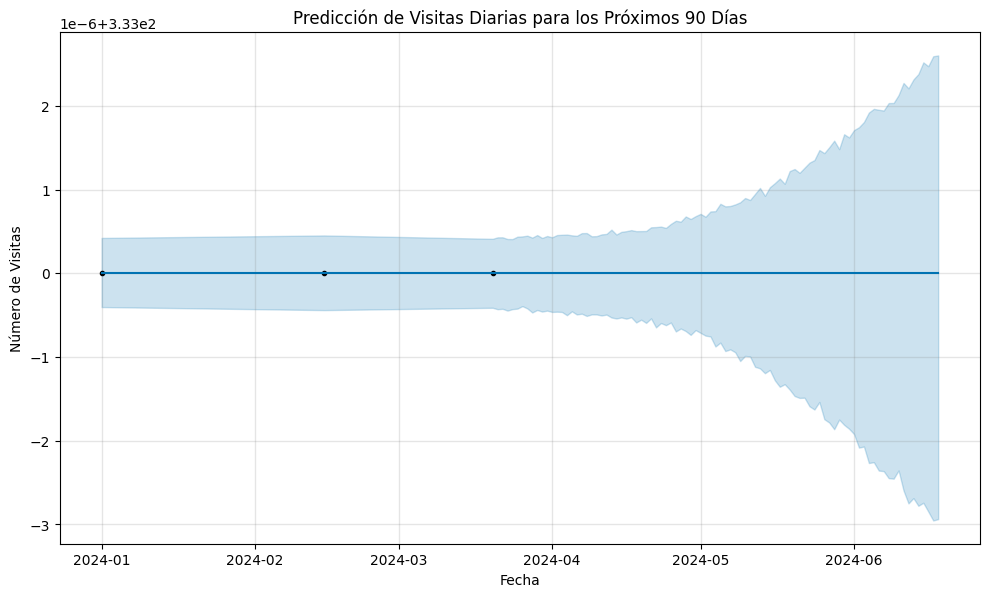

In [39]:
# --- Celda 6.2: Predicción de Demanda con Prophet ---

print("\n--- Paso 6.2: Predicción de Demanda con Prophet ---")
try:
    from prophet import Prophet
    import matplotlib.pyplot as plt

    # Preparar los datos para series de tiempo
    df_demand = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_UserHistory.csv"))
    if df_demand.empty:
        raise ValueError("El DataFrame de demanda está vacío.")
    if 'VisitDate' not in df_demand.columns:
        raise ValueError("La columna 'VisitDate' no existe en df_demand.")
    df_demand['VisitDate'] = pd.to_datetime(df_demand['VisitDate'])

    # Contar visitas diarias
    daily_demand = df_demand.groupby('VisitDate').size().reset_index(name='visits')
    daily_demand = daily_demand.rename(columns={'VisitDate': 'ds', 'visits': 'y'})
    if daily_demand.empty:
        raise ValueError("No hay datos suficientes para la predicción de demanda.")

    # Inicializar y entrenar el modelo Prophet
    model_prophet = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False).add_seasonality(name='monthly', period=30.5, fourier_order=5)
    model_prophet.fit(daily_demand)

    # Crear un dataframe futuro para predecir
    future = model_prophet.make_future_dataframe(periods=90) # Predecir los próximos 3 meses
    forecast = model_prophet.predict(future)

    # Visualizar la predicción
    print("\n--- Predicción de Demanda General de Viajes ---")
    fig1 = model_prophet.plot(forecast)
    plt.title('Predicción de Visitas Diarias para los Próximos 90 Días')
    plt.xlabel('Fecha')
    plt.ylabel('Número de Visitas')
    plt.grid(True)
    plt.show()
except Exception as e:
    print(f"Error en la predicción de demanda con Prophet: {str(e)}")

### **Predicción de Demanda y Planificación Estratégica**
La predicción de demanda mediante modelos de series de tiempo permite anticipar tendencias y optimizar la asignación de recursos. Integrar esta información con el sistema de recomendación potencia la toma de decisiones y la capacidad de respuesta ante cambios en el mercado turístico.

# **7. Guardado de Artefactos del Modelo para Producción**
**El Qué:** Se guardan los componentes esenciales del modelo en un único archivo `.pkl`.
**El Porqué:** Para poder utilizar este sistema de recomendación en una aplicación real (como una página web o una app móvil), necesitamos una forma de cargar el modelo entrenado y todos los datos de mapeo necesarios sin tener que volver a entrenarlo cada vez. El archivo `.pkl` actúa como un "paquete" que contiene todo lo necesario para hacer predicciones en un entorno de producción.

In [ ]:
# --- Celda 7: Guardar artefactos del modelo ---
import pickle

print("\n--- Paso 8.1: Guardando artefactos del modelo para producción ---")

# 1. Crear un diccionario con los objetos a guardar
# Guardamos el modelo, el dataset (que contiene los mapeos) y los dataframes de destinos y usuarios
# para poder obtener información legible por humanos a partir de las recomendaciones.
artifacts = {
    'model': model3,
    'dataset': dataset1,
    'df_dest': df_dest,
    'df_users': df_users,
    'df_interactions_combined': df_interactions_combined
}

# 2. Guardar el diccionario en un archivo .pkl
# Usamos una ruta genérica que funcione en cualquier entorno
file_path = "recommendation_artifacts.pkl"
with open(file_path, 'wb') as f:
    pickle.dump(artifacts, f)

print(f"\nArtefactos del modelo guardados exitosamente en: {file_path}")
print("Este archivo contiene:")
for key in artifacts.keys():
    print(f"  - {key}")

# Ejemplo de cómo se cargaría en otra aplicación:
# with open('recommendation_artifacts.pkl', 'rb') as f:
#     loaded_artifacts = pickle.load(f)
# model = loaded_artifacts['model']
# dataset = loaded_artifacts['dataset']
# ... y así sucesivamente


--- Paso 8.1: Guardando artefactos del modelo para producción ---

Artefactos del modelo guardados exitosamente en: recommendation_artifacts.pkl
Este archivo contiene:
  - model
  - dataset
  - df_dest
  - df_users
  - df_interactions_combined


---

# **8. Glosario de Términos**

- **AUC (Area Under Curve):** Métrica que mide la capacidad de un modelo para distinguir entre clases. Un valor de 0.5 indica rendimiento aleatorio, mientras que valores cercanos a 1.0 indican alta capacidad predictiva.
- **Feedback implícito:** Interacciones del usuario que no son calificaciones directas, como clics, visitas o compras.
- **Cold start:** Problema en sistemas de recomendación cuando hay poca información sobre nuevos usuarios o ítems.
- **LightFM:** Algoritmo de recomendación híbrido que combina métodos de filtrado colaborativo y de contenido.
- **Prophet:** Modelo de series de tiempo desarrollado por Facebook, útil para predicción de demanda y tendencias.
- **Binarización:** Proceso de convertir una variable continua o categórica en una variable binaria (0/1).

---

# **9. Referencias y Recursos Adicionales**

- [Documentación oficial de LightFM](https://making.lyst.com/lightfm/docs/home.html)
- [Documentación oficial de Prophet](https://facebook.github.io/prophet/docs/quick_start.html)
- [Artículo: Recommender Systems in Python](https://realpython.com/build-recommendation-engine-collaborative-filtering/)
- [Artículo: Evaluating Recommender Systems](https://towardsdatascience.com/evaluating-recommender-systems-769c6cf9a1e9)

---

# **10. Preguntas Frecuentes (FAQ)**

**¿Por qué el modelo no mejora con más datos sintéticos?**
- Porque los datos sintéticos pueden carecer de patrones reales y coherentes, limitando la capacidad de aprendizaje del modelo.

**¿Qué significa AUC cercano a 0.5?**
- Indica que el modelo no está aprendiendo patrones útiles y su rendimiento es similar al azar.

**¿Cómo se puede mejorar el sistema?**
- Integrando datos reales, enriqueciendo las variables y validando continuamente el pipeline.

**¿Qué hacer ante el problema de cold start?**
- Incorporar características de usuario e ítem, y recolectar más interacciones reales.

**¿Por qué se usa LightFM y Prophet?**
- LightFM permite modelos híbridos y maneja feedback implícito/explicito; Prophet es robusto para predicción de series de tiempo y demanda.

---